# Рынок жилой недвижимости Казани в 2025 году: исследовательский анализ

Анализ разделяет количество договоров и количество объектов недвижимости. Цены отдельных помещений рассматриваются только для договоров с одним объектом, поскольку `deal_price` содержит общую стоимость всего договора.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
INPUT_FILE = DATA_DIR / "kazan_residential_transactions_2025_clean.csv"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        "Сначала выполните ноутбук 03_data_cleaning.ipynb. "
        f"Ожидаемый файл: {INPUT_FILE}"
    )

data = pd.read_csv(
    INPUT_FILE,
    parse_dates=["period_start_date"],
    encoding="utf-8",
)

boolean_columns = [
    "is_single_property_contract",
    "is_multi_property_contract",
    "needs_price_review",
    "has_complete_area_data",
    "is_area_missing",
]
for column in boolean_columns:
    data[column] = data[column].replace({"True": True, "False": False})
    data[column] = data[column].fillna(False).astype(bool)

expected_districts = [
    "Авиастроительный",
    "Вахитовский",
    "Кировский",
    "Московский",
    "Ново-Савиновский",
    "Приволжский",
    "Советский",
]
unexpected_district = (
    data["district"].notna()
    & ~data["district"].isin(expected_districts)
)
if unexpected_district.sum() > 0:
    raise ValueError(
        "Перезапустите 03_data_cleaning.ipynb: район ещё не обновлён по ОКАТО"
    )

quarter_order = ["Q1", "Q2", "Q3", "Q4"]
yellow = "#FFDD2D"
dark = "#333333"
gray = "#A0A0A0"

print(f"Договоров: {len(data):,}")
print(f"Объектов в договорах: {data['property_count'].sum():,.0f}")
data.head()

Договоров: 5,584
Объектов в договорах: 16,693


,property_count,okato,district,quarter_cad_number,street,realestate_type_code,wall_material_code,year_build,floor,purpose_code,area,period_start_date,deal_price,doc_type,quarter,floor_raw,is_single_property_contract,is_multi_property_contract,contract_segment,price_per_sqm,needs_price_review,has_complete_area_data,is_area_missing
0,1,92401380000,Приволжский,16:50:160205,Хусаина Мавлютова,2001003000,061001001001,1986.0,9.0,206002000000,56.90,2025-01-01,8900000.0,ДКП,Q1,9,True,False,один объект,156414.762742,False,True,False
1,3,92401367000,Вахитовский,16:50:011102,Старая,2001003000,NaN,NaN,NaN,206002000000,7991.31,2025-01-01,54923916.0,ДДУ,Q1,NaN,False,True,несколько объектов,NaN,False,True,False
2,1,92401367000,Вахитовский,16:50:011705,Николая Столбова,2001003000,061001003000,2020.0,2.0,206002000000,62.10,2025-01-01,26400000.0,ДКП,Q1,2,True,False,один объект,425120.772947,False,True,False
3,1,92401385000,Советский,16:50:060510,Комарова,2001003000,061001007001,1969.0,5.0,206002000000,59.40,2025-01-01,9000000.0,ДКП,Q1,5,True,False,один объект,151515.151515,False,True,False
4,1,92401363000,Авиастроительный,16:50:220526,Молодежная,2001003000,061001001001,1982.0,5.0,206002000000,12.90,2025-01-01,2200000.0,ДКП,Q1,5,True,False,один объект,170542.635659,False,True,False


## 1. Сколько договоров и объектов регистрировалось по кварталам?

Количество договоров измеряет регистрационную активность, а сумма `property_count` — объём объектов внутри этих договоров. Эти показатели нельзя считать взаимозаменяемыми.

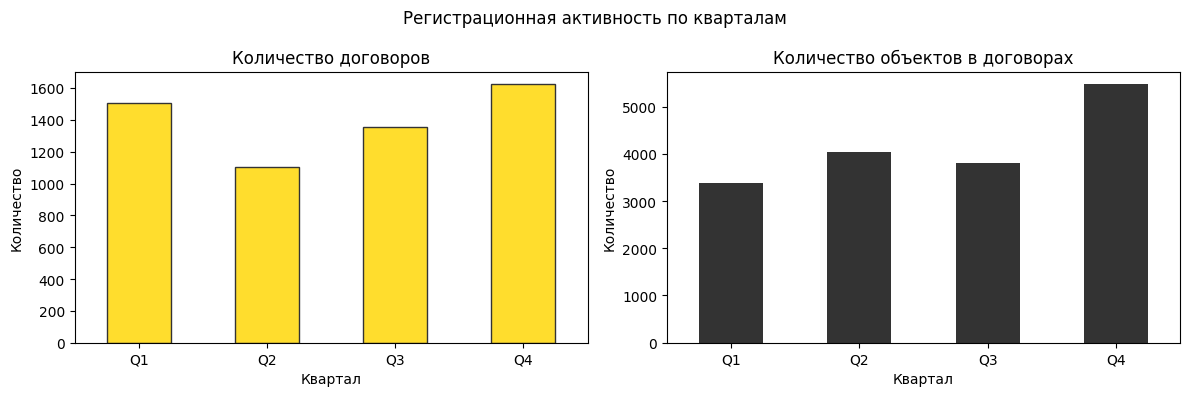

,quarter,doc_type,договоров,объектов
0,Q1,ДДУ,71,1865
1,Q1,ДКП,1434,1519
2,Q2,ДДУ,74,2962
3,Q2,ДКП,1028,1072
4,Q3,ДДУ,79,2436
5,Q3,ДКП,1276,1371
6,Q4,ДДУ,78,3787
7,Q4,ДКП,1544,1681


In [20]:
quarter_groups = data.groupby("quarter")
quarter_activity = quarter_groups.agg(
    договоров=("quarter", "size"),
    объектов=("property_count", "sum"),
)
quarter_activity = quarter_activity.reindex(quarter_order)

quarter_doc_groups = data.groupby(["quarter", "doc_type"])
quarter_doc_activity = quarter_doc_groups.agg(
    договоров=("doc_type", "size"),
    объектов=("property_count", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
quarter_activity["договоров"].plot(
    kind="bar", ax=axes[0], color=yellow, edgecolor=dark
)
quarter_activity["объектов"].plot(
    kind="bar", ax=axes[1], color=dark
)
axes[0].set_title("Количество договоров")
axes[1].set_title("Количество объектов в договорах")
for axis in axes:
    axis.set_xlabel("Квартал")
    axis.set_ylabel("Количество")
    axis.tick_params(axis="x", rotation=0)
fig.suptitle("Регистрационная активность по кварталам")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_market_activity.png", dpi=150, bbox_inches="tight")
plt.show()

quarter_doc_activity

## 2. Какую долю рынка составляют одиночные и многообъектные договоры?

Договор с одним объектом используется как приближение к обычной покупке домохозяйства, а многообъектный договор — к оптовой или институциональной активности. Тип покупателя в данных отсутствует, поэтому это только аналитические прокси.

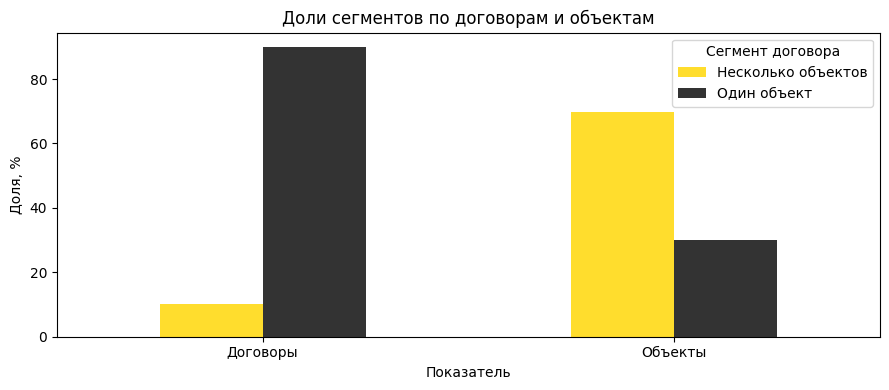

,договоров,объектов,записанная_площадь,стоимость_договоров,доля_договоров_проц,доля_объектов_проц,доля_площади_проц,доля_стоимости_проц
contract_segment,,,,,,,,
несколько объектов,562,11671,5.430991e+07,1.396542e+11,10.06,69.92,99.54,78.36
один объект,5022,5022,2.500622e+05,3.855916e+10,89.94,30.08,0.46,21.64


In [21]:
segment_groups = data.groupby("contract_segment")
segment_summary = segment_groups.agg(
    договоров=("contract_segment", "size"),
    объектов=("property_count", "sum"),
    записанная_площадь=("area", "sum"),
    стоимость_договоров=("deal_price", "sum"),
)

segment_summary["доля_договоров_проц"] = (
    segment_summary["договоров"] / segment_summary["договоров"].sum() * 100
).round(2)
segment_summary["доля_объектов_проц"] = (
    segment_summary["объектов"] / segment_summary["объектов"].sum() * 100
).round(2)
segment_summary["доля_площади_проц"] = (
    segment_summary["записанная_площадь"]
    / segment_summary["записанная_площадь"].sum()
    * 100
).round(2)
segment_summary["доля_стоимости_проц"] = (
    segment_summary["стоимость_договоров"]
    / segment_summary["стоимость_договоров"].sum()
    * 100
).round(2)

segment_shares = segment_summary[["доля_договоров_проц", "доля_объектов_проц"]].T
segment_shares = segment_shares.rename(
    index={
        "доля_договоров_проц": "Договоры",
        "доля_объектов_проц": "Объекты",
    },
    columns={
        "несколько объектов": "Несколько объектов",
        "один объект": "Один объект",
    },
)
fig, axis = plt.subplots(figsize=(9, 4))
segment_shares.plot(
    kind="bar", ax=axis, color=[yellow, dark]
)
axis.set_title("Доли сегментов по договорам и объектам")
axis.set_xlabel("Показатель")
axis.set_ylabel("Доля, %")
axis.tick_params(axis="x", rotation=0)
axis.legend(title="Сегмент договора")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_contract_segments.png", dpi=150, bbox_inches="tight")
plt.show()

segment_summary

**Ограничение:** для многообъектных договоров `area` показывается как записанная в источнике площадь. Без дополнительной документации она не интерпретируется как сумма площадей отдельных квартир.

## 3. Насколько объём рынка сконцентрирован в крупнейших договорах?

Рассчитывается доля объектов, содержащихся в крупнейших многообъектных договорах. Это показывает, насколько общий объём зависит от небольшого числа регистраций.

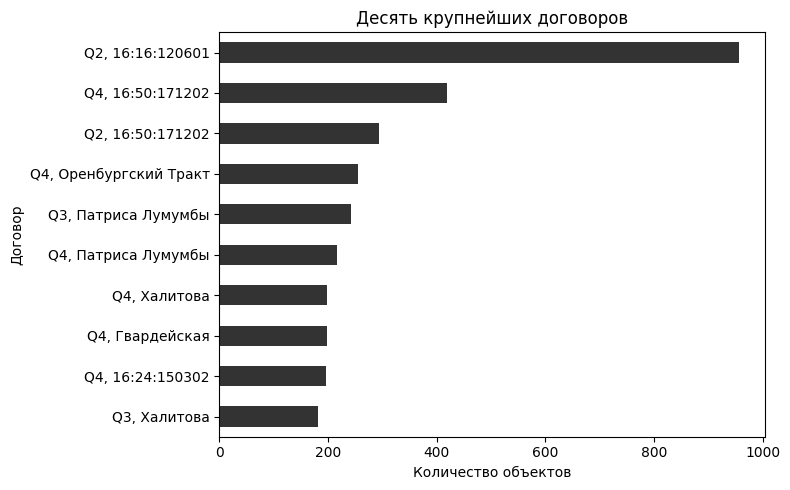

,крупнейших_договоров,объектов,доля_всех_объектов_проц,доля_объектов_многообъектных_договоров_проц
0,1,956,5.73,8.19
1,5,2166,12.98,18.56
2,10,3156,18.91,27.04
3,25,4966,29.75,42.55


,quarter,doc_type,district,quarter_cad_number,street,property_count,area,deal_price,подпись
1515,Q2,ДДУ,NaN,16:16:120601,NaN,956,39262.43,6.716958e+09,"Q2, 16:16:120601"
4140,Q4,ДДУ,NaN,16:50:171202,NaN,419,13505.29,3.374853e+09,"Q4, 16:50:171202"
1707,Q2,ДДУ,NaN,16:50:171202,NaN,294,9425.98,2.233351e+09,"Q2, 16:50:171202"
4156,Q4,ДДУ,Приволжский,16:50:171202,Оренбургский Тракт,255,11366.86,2.331386e+09,"Q4, Оренбургский Тракт"
3632,Q3,ДДУ,Советский,16:50:060102,Патриса Лумумбы,242,10950.99,2.539309e+09,"Q3, Патриса Лумумбы"
4097,Q4,ДДУ,NaN,16:50:060102,Патриса Лумумбы,217,10355.77,2.580769e+09,"Q4, Патриса Лумумбы"
4084,Q4,ДДУ,Советский,16:50:060501,Гвардейская,198,7896.67,1.902794e+09,"Q4, Гвардейская"
4215,Q4,ДДУ,Советский,16:50:050202,Халитова,198,7486.30,2.500377e+09,"Q4, Халитова"
4605,Q4,ДДУ,NaN,16:24:150302,NaN,196,6986.71,1.369570e+09,"Q4, 16:24:150302"
3755,Q3,ДДУ,Советский,16:50:050202,Халитова,181,7161.98,1.544560e+09,"Q3, Халитова"


In [22]:
bulk_contracts = data.loc[data["is_multi_property_contract"]].copy()
bulk_contracts = bulk_contracts.sort_values(
    "property_count", ascending=False
)

total_objects = data["property_count"].sum()
bulk_objects = bulk_contracts["property_count"].sum()
top_sizes = [1, 5, 10, 25]
concentration_rows = []

for top_n in top_sizes:
    objects_in_top = bulk_contracts.head(top_n)["property_count"].sum()
    concentration_rows.append(
        {
            "крупнейших_договоров": top_n,
            "объектов": objects_in_top,
            "доля_всех_объектов_проц": round(objects_in_top / total_objects * 100, 2),
            "доля_объектов_многообъектных_договоров_проц": round(objects_in_top / bulk_objects * 100, 2),
        }
    )

concentration_summary = pd.DataFrame(concentration_rows)
top_contracts = bulk_contracts.head(10)[
    [
        "quarter",
        "doc_type",
        "district",
        "quarter_cad_number",
        "street",
        "property_count",
        "area",
        "deal_price",
    ]
]
top_contracts["подпись"] = (
    top_contracts["quarter"]
    + ", "
    + top_contracts["street"].fillna(top_contracts["quarter_cad_number"])
)

top_contracts_for_plot = top_contracts.set_index("подпись")
fig, axis = plt.subplots(figsize=(8, 5))
top_contracts_for_plot["property_count"].sort_values().plot(
    kind="barh", ax=axis, color=dark
)
axis.set_title("Десять крупнейших договоров")
axis.set_xlabel("Количество объектов")
axis.set_ylabel("Договор")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_bulk_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

display(concentration_summary)
top_contracts

## 4. Чем различается структура ДКП и ДДУ?

Сравниваются количество объектов в договоре и полнота характеристик здания. ДКП нельзя автоматически считать вторичным рынком, а ДДУ — отдельной квартирой в новостройке.

In [23]:
document_data = data.copy()
document_data["year_missing"] = document_data["year_build"].isna()
document_data["floor_missing"] = document_data["floor"].isna()
document_data["wall_missing"] = document_data["wall_material_code"].isna()
document_data["area_missing"] = document_data["area"].isna()

document_groups = document_data.groupby("doc_type")
document_summary = document_groups.agg(
    договоров=("doc_type", "size"),
    объектов=("property_count", "sum"),
    медиана_объектов_в_договоре=("property_count", "median"),
    максимум_объектов_в_договоре=("property_count", "max"),
    многообъектных_договоров=("is_multi_property_contract", "sum"),
    пропусков_года=("year_missing", "sum"),
    пропусков_этажа=("floor_missing", "sum"),
    пропусков_материала_стен=("wall_missing", "sum"),
    пропусков_площади=("area_missing", "sum"),
)
document_summary["объектов_на_договор"] = (
    document_summary["объектов"] / document_summary["договоров"]
).round(2)
document_summary["доля_многообъектных_проц"] = (
    document_summary["многообъектных_договоров"]
    / document_summary["договоров"]
    * 100
).round(2)
document_summary

,договоров,объектов,медиана_объектов_в_договоре,максимум_объектов_в_договоре,многообъектных_договоров,пропусков_года,пропусков_этажа,пропусков_материала_стен,пропусков_площади,объектов_на_договор,доля_многообъектных_проц
doc_type,,,,,,,,,,,
ДДУ,302,11050,15.0,956,270,298,298,298,6,36.59,89.40
ДКП,5282,5643,1.0,7,292,17,6,14,0,1.07,5.53


## 5. Как менялись цены отдельных помещений по кварталам?

Используются только договоры с одним объектом. Основной показатель — медиана: она устойчивее среднего значения к редким экстремальным сделкам.

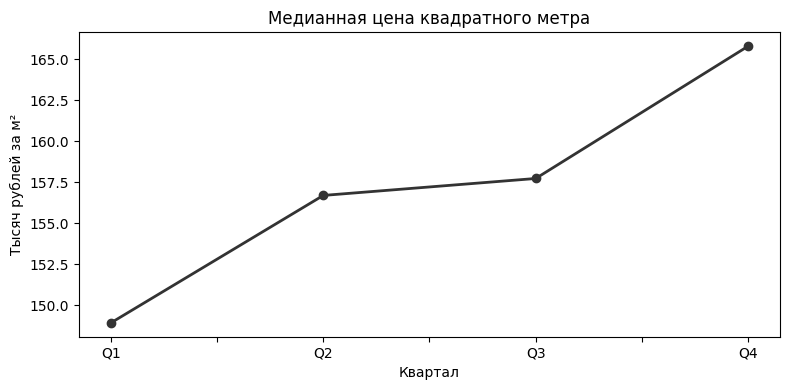

,договоров,медианная_цена,медианная_цена_кв_м,медианная_площадь,медианная_цена_млн,медианная_цена_кв_м_тыс
quarter,,,,,,
Q1,1365,6350000.0,148921.282799,43.30,6.35,148.921283
Q2,994,6600000.0,156690.964026,44.65,6.60,156.690964
Q3,1214,6550000.0,157724.043133,43.00,6.55,157.724043
Q4,1449,6900000.0,165789.473684,42.30,6.90,165.789474


In [24]:
single_property = data.loc[data["is_single_property_contract"]].copy()

single_quarter_groups = single_property.groupby("quarter")
quarter_price_summary = single_quarter_groups.agg(
    договоров=("quarter", "size"),
    медианная_цена=("deal_price", "median"),
    медианная_цена_кв_м=("price_per_sqm", "median"),
    медианная_площадь=("area", "median"),
)
quarter_price_summary = quarter_price_summary.reindex(quarter_order)
quarter_price_summary["медианная_цена_млн"] = (
    quarter_price_summary["медианная_цена"] / 1_000_000
)
quarter_price_summary["медианная_цена_кв_м_тыс"] = (
    quarter_price_summary["медианная_цена_кв_м"] / 1_000
)

fig, axis = plt.subplots(figsize=(8, 4))
quarter_price_summary["медианная_цена_кв_м_тыс"].plot(
    kind="line", marker="o", ax=axis, color=dark, linewidth=2
)
axis.set_title("Медианная цена квадратного метра")
axis.set_xlabel("Квартал")
axis.set_ylabel("Тысяч рублей за м²")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_quarterly_prices.png", dpi=150, bbox_inches="tight")
plt.show()

quarter_price_summary

## 6. Какие районы были наиболее активными, дорогими и доступными?

Активность считается по всем договорам с известным районом, а цены — только по одиночным. Район отсутствует у 19,4% строк, поэтому районные результаты описывают неполную выборку и могут быть смещены.

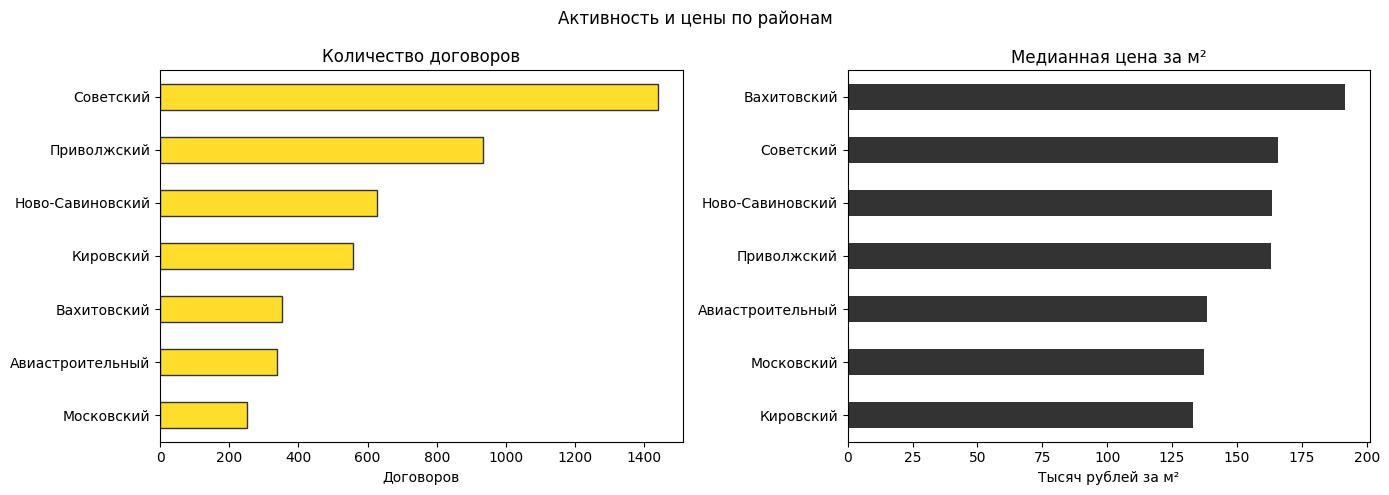

Доля строк с известным районом: 80.6%


,district,всех_договоров,объектов,одиночных_договоров,медианная_цена,медианная_цена_кв_м,медианная_площадь,медианная_цена_млн,медианная_цена_кв_м_тыс
1,Вахитовский,352,892,298,9250000.0,191722.824540,47.85,9.25,191.722825
6,Советский,1439,4169,1308,7050000.0,165777.619725,42.90,7.05,165.777620
4,Ново-Савиновский,628,954,581,7350000.0,163323.782235,47.50,7.35,163.323782
5,Приволжский,935,2315,848,6900000.0,163235.294118,43.50,6.90,163.235294
0,Авиастроительный,338,370,326,5100000.0,138380.966093,36.75,5.10,138.380966
3,Московский,250,319,226,5500000.0,137470.379147,43.20,5.50,137.470379
2,Кировский,559,755,506,5300000.0,133024.870339,41.40,5.30,133.024870


In [25]:
known_district = data.loc[data["district"].notna()].copy()
known_district_single = single_property.loc[
    single_property["district"].notna()
].copy()

district_activity_groups = known_district.groupby("district")
district_activity = district_activity_groups.agg(
    всех_договоров=("district", "size"),
    объектов=("property_count", "sum"),
).reset_index()

district_price_groups = known_district_single.groupby("district")
district_prices = district_price_groups.agg(
    одиночных_договоров=("district", "size"),
    медианная_цена=("deal_price", "median"),
    медианная_цена_кв_м=("price_per_sqm", "median"),
    медианная_площадь=("area", "median"),
).reset_index()

district_summary = district_activity.merge(
    district_prices, on="district", how="left"
)
district_summary = district_summary.sort_values(
    "медианная_цена_кв_м", ascending=False
)
district_summary["медианная_цена_млн"] = (
    district_summary["медианная_цена"] / 1_000_000
)
district_summary["медианная_цена_кв_м_тыс"] = (
    district_summary["медианная_цена_кв_м"] / 1_000
)

district_plot = district_summary.set_index("district")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
district_plot["всех_договоров"].sort_values().plot(
    kind="barh", ax=axes[0], color=yellow, edgecolor=dark
)
district_plot["медианная_цена_кв_м_тыс"].sort_values().plot(
    kind="barh", ax=axes[1], color=dark
)
axes[0].set_title("Количество договоров")
axes[1].set_title("Медианная цена за м²")
axes[0].set_xlabel("Договоров")
axes[1].set_xlabel("Тысяч рублей за м²")
for axis in axes:
    axis.set_ylabel("")
fig.suptitle("Активность и цены по районам")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_districts.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Доля строк с известным районом: {len(known_district) / len(data) * 100:.1f}%")
district_summary

## 7. Как площадь связана с ценой и ценой квадратного метра?

Одиночные договоры делятся на понятные покупателю размерные группы. Для диаграммы зависимости используются строки без диагностического флага, чтобы экстремальные значения не сжимали основную часть графика.

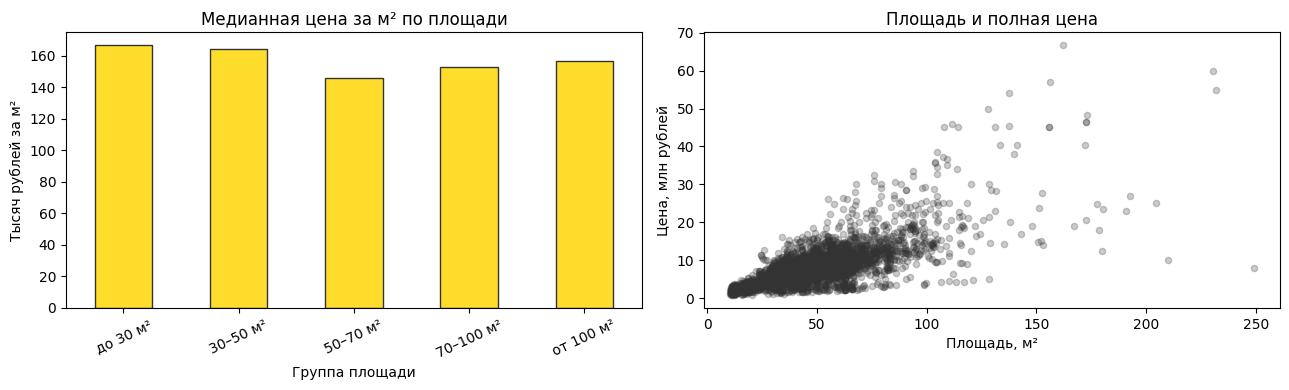

,договоров,медианная_площадь,медианная_цена,медианная_цена_кв_м,медианная_цена_млн,медианная_цена_кв_м_тыс
area_group,,,,,,
до 30 м²,849,18.40,3050000.0,166666.666667,3.050000,166.666667
30–50 м²,2361,38.50,6250000.0,164351.851852,6.250000,164.351852
50–70 м²,1250,58.30,8400000.0,145988.724722,8.400000,145.988725
70–100 м²,420,81.00,12489499.0,152779.821738,12.489499,152.779822
от 100 м²,140,115.95,20550000.0,156650.197850,20.550000,156.650198


In [26]:
area_analysis = single_property.copy()
area_analysis["area_group"] = pd.NA
area_analysis.loc[area_analysis["area"] < 30, "area_group"] = "до 30 м²"
area_analysis.loc[
    (area_analysis["area"] >= 30) & (area_analysis["area"] < 50),
    "area_group",
] = "30–50 м²"
area_analysis.loc[
    (area_analysis["area"] >= 50) & (area_analysis["area"] < 70),
    "area_group",
] = "50–70 м²"
area_analysis.loc[
    (area_analysis["area"] >= 70) & (area_analysis["area"] < 100),
    "area_group",
] = "70–100 м²"
area_analysis.loc[area_analysis["area"] >= 100, "area_group"] = "от 100 м²"

area_order = ["до 30 м²", "30–50 м²", "50–70 м²", "70–100 м²", "от 100 м²"]
area_groups = area_analysis.groupby("area_group")
area_summary = area_groups.agg(
    договоров=("area_group", "size"),
    медианная_площадь=("area", "median"),
    медианная_цена=("deal_price", "median"),
    медианная_цена_кв_м=("price_per_sqm", "median"),
)
area_summary = area_summary.reindex(area_order)
area_summary["медианная_цена_млн"] = area_summary["медианная_цена"] / 1_000_000
area_summary["медианная_цена_кв_м_тыс"] = (
    area_summary["медианная_цена_кв_м"] / 1_000
)

stable_area = area_analysis.loc[~area_analysis["needs_price_review"]].copy()
stable_area["deal_price_mln"] = stable_area["deal_price"] / 1_000_000
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
area_summary["медианная_цена_кв_м_тыс"].plot(
    kind="bar", ax=axes[0], color=yellow, edgecolor=dark
)
stable_area.plot.scatter(
    x="area", y="deal_price_mln", ax=axes[1], alpha=0.25, color=dark
)
axes[0].set_title("Медианная цена за м² по площади")
axes[0].set_xlabel("Группа площади")
axes[0].set_ylabel("Тысяч рублей за м²")
axes[0].tick_params(axis="x", rotation=25)
axes[1].set_title("Площадь и полная цена")
axes[1].set_xlabel("Площадь, м²")
axes[1].set_ylabel("Цена, млн рублей")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_area_relationship.png", dpi=150, bbox_inches="tight")
plt.show()

area_summary

## 8. Как характеристики здания связаны с ценой квадратного метра?

Рассматриваются одиночные ДКП без ценового флага: у них почти полностью заполнены год, этаж и материал стен. Результаты показывают связь признаков с ценой, но не доказывают причинность.

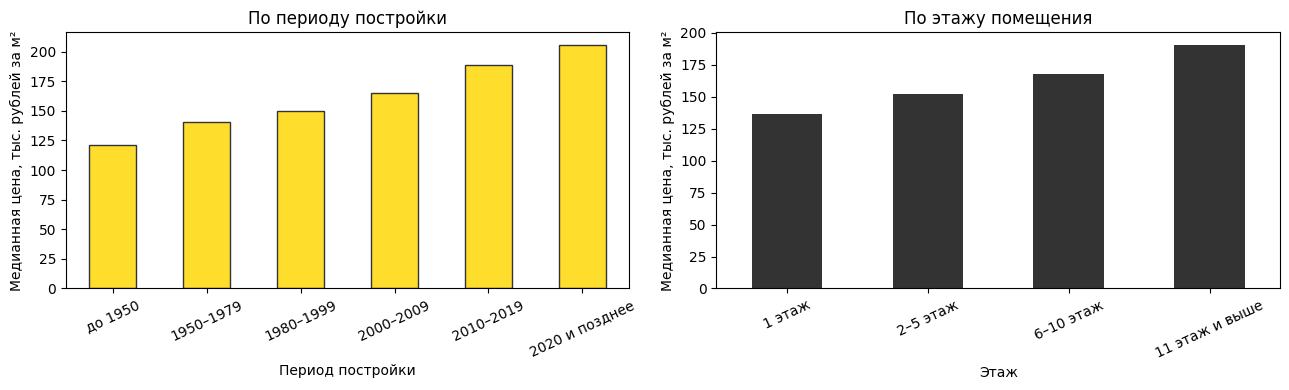

,договоров,медианная_цена_кв_м,медианная_цена_кв_м_тыс
year_group,,,
до 1950,68,121177.512586,121.177513
1950–1979,1602,140645.362909,140.645363
1980–1999,1000,150085.089387,150.085089
2000–2009,524,165380.847854,165.380848
2010–2019,929,188552.188552,188.552189
2020 и позднее,711,205947.242206,205.947242


,договоров,медианная_цена_кв_м,медианная_цена_кв_м_тыс
floor_group,,,
1 этаж,466,136418.718666,136.418719
2–5 этаж,2433,152233.676976,152.233677
6–10 этаж,1328,167542.945668,167.542946
11 этаж и выше,616,190925.781685,190.925782


,договоров,медианная_цена_кв_м
wall_material_code,,
061001999000,33,256133.333333
061001003000,319,202956.989247
061001006001,63,189915.966387
061001005000,820,175347.038376
061001007003,45,174080.882353
061001006000,85,159090.909091
061001001001,2246,153892.255005
061001007000,477,150300.601202
061001001000,45,149532.710280


In [27]:
building_data = single_property.loc[
    (single_property["doc_type"] == "ДКП")
    & ~single_property["needs_price_review"]
].copy()

building_data["year_group"] = pd.NA
building_data.loc[building_data["year_build"] < 1950, "year_group"] = "до 1950"
building_data.loc[
    (building_data["year_build"] >= 1950) & (building_data["year_build"] < 1980),
    "year_group",
] = "1950–1979"
building_data.loc[
    (building_data["year_build"] >= 1980) & (building_data["year_build"] < 2000),
    "year_group",
] = "1980–1999"
building_data.loc[
    (building_data["year_build"] >= 2000) & (building_data["year_build"] < 2010),
    "year_group",
] = "2000–2009"
building_data.loc[
    (building_data["year_build"] >= 2010) & (building_data["year_build"] < 2020),
    "year_group",
] = "2010–2019"
building_data.loc[building_data["year_build"] >= 2020, "year_group"] = "2020 и позднее"
year_order = ["до 1950", "1950–1979", "1980–1999", "2000–2009", "2010–2019", "2020 и позднее"]

building_data["floor_group"] = pd.NA
building_data.loc[building_data["floor"] == 1, "floor_group"] = "1 этаж"
building_data.loc[
    (building_data["floor"] >= 2) & (building_data["floor"] <= 5),
    "floor_group",
] = "2–5 этаж"
building_data.loc[
    (building_data["floor"] >= 6) & (building_data["floor"] <= 10),
    "floor_group",
] = "6–10 этаж"
building_data.loc[building_data["floor"] >= 11, "floor_group"] = "11 этаж и выше"
floor_order = ["1 этаж", "2–5 этаж", "6–10 этаж", "11 этаж и выше"]

year_summary = building_data.groupby("year_group").agg(
    договоров=("year_group", "size"),
    медианная_цена_кв_м=("price_per_sqm", "median"),
).reindex(year_order)
floor_summary = building_data.groupby("floor_group").agg(
    договоров=("floor_group", "size"),
    медианная_цена_кв_м=("price_per_sqm", "median"),
).reindex(floor_order)
wall_summary = building_data.groupby("wall_material_code").agg(
    договоров=("wall_material_code", "size"),
    медианная_цена_кв_м=("price_per_sqm", "median"),
)
wall_summary = wall_summary.loc[wall_summary["договоров"] >= 30]
wall_summary = wall_summary.sort_values("медианная_цена_кв_м", ascending=False)
year_summary["медианная_цена_кв_м_тыс"] = (
    year_summary["медианная_цена_кв_м"] / 1_000
)
floor_summary["медианная_цена_кв_м_тыс"] = (
    floor_summary["медианная_цена_кв_м"] / 1_000
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
year_summary["медианная_цена_кв_м_тыс"].plot(
    kind="bar", ax=axes[0], color=yellow, edgecolor=dark
)
floor_summary["медианная_цена_кв_м_тыс"].plot(
    kind="bar", ax=axes[1], color=dark
)
axes[0].set_title("По периоду постройки")
axes[1].set_title("По этажу помещения")
axes[0].set_xlabel("Период постройки")
axes[1].set_xlabel("Этаж")
for axis in axes:
    axis.set_ylabel("Медианная цена, тыс. рублей за м²")
    axis.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_building_characteristics.png", dpi=150, bbox_inches="tight")
plt.show()

display(year_summary)
display(floor_summary)
wall_summary

Материал стен пока представлен кодом Росреестра. Таблица ограничена категориями минимум с 30 договорами; содержательные названия следует добавить только после получения официальной расшифровки кодов.

## 9. Насколько выводы зависят от необычных наблюдений и пропусков района?

Сравниваются медианы для всех одиночных договоров и для выборки без диагностического ценового флага. Отдельно проверяется, отличается ли группа с неизвестным районом от размеченной части данных.

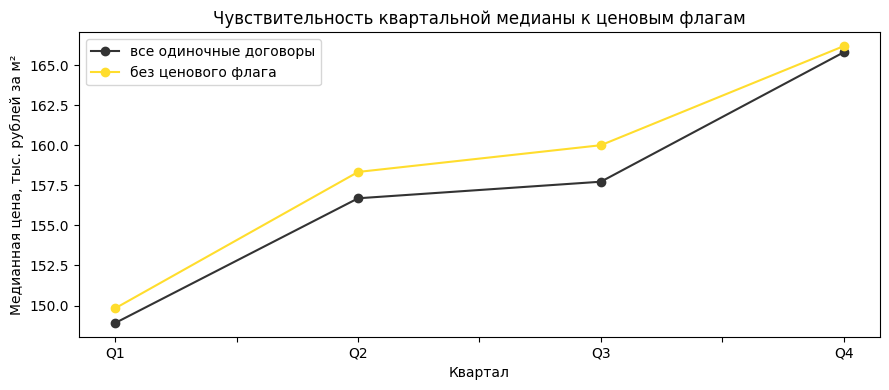

,выборка,договоров,медианная_цена,медианная_цена_кв_м,медианная_площадь
0,все одиночные договоры,5022,6600000.0,157736.119378,43.2
1,без ценового флага,4876,6700000.0,159235.668790,43.0


,все одиночные договоры,без ценового флага
quarter,,
Q1,148921.282799,149838.247150
Q2,156690.964026,158333.333333
Q3,157724.043133,160000.000000
Q4,165789.473684,166175.887283


,договоров,медианная_цена,медианная_цена_кв_м,медианная_площадь
district_status,,,,
район известен,4093,6600000.0,158402.677487,43.2
район неизвестен,929,6550000.0,155070.110240,43.2


In [28]:
stable_single = single_property.loc[
    ~single_property["needs_price_review"]
].copy()

sensitivity_summary = pd.DataFrame(
    {
        "выборка": ["все одиночные договоры", "без ценового флага"],
        "договоров": [len(single_property), len(stable_single)],
        "медианная_цена": [
            single_property["deal_price"].median(),
            stable_single["deal_price"].median(),
        ],
        "медианная_цена_кв_м": [
            single_property["price_per_sqm"].median(),
            stable_single["price_per_sqm"].median(),
        ],
        "медианная_площадь": [
            single_property["area"].median(),
            stable_single["area"].median(),
        ],
    }
)

all_quarter_median = single_property.groupby("quarter")["price_per_sqm"].median()
stable_quarter_median = stable_single.groupby("quarter")["price_per_sqm"].median()
quarter_sensitivity = pd.DataFrame(
    {
        "все одиночные договоры": all_quarter_median,
        "без ценового флага": stable_quarter_median,
    }
).reindex(quarter_order)
quarter_sensitivity_thousands = quarter_sensitivity / 1_000

single_property["district_status"] = "район известен"
single_property.loc[
    single_property["district"].isna(), "district_status"
] = "район неизвестен"
district_status_summary = single_property.groupby("district_status").agg(
    договоров=("district_status", "size"),
    медианная_цена=("deal_price", "median"),
    медианная_цена_кв_м=("price_per_sqm", "median"),
    медианная_площадь=("area", "median"),
)

fig, axis = plt.subplots(figsize=(9, 4))
quarter_sensitivity_thousands.plot(
    kind="line", marker="o", ax=axis, color=[dark, yellow]
)
axis.set_title("Чувствительность квартальной медианы к ценовым флагам")
axis.set_xlabel("Квартал")
axis.set_ylabel("Медианная цена, тыс. рублей за м²")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_outlier_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

display(sensitivity_summary)
display(quarter_sensitivity)
district_status_summary

## Основные результаты

- 5 584 договора охватывают 16 693 объекта недвижимости. Максимальная активность наблюдается в Q4: 1 622 договора и 5 468 объектов.
- Многообъектные сделки составляют только 10,1% договоров, но включают 69,9% объектов и 78,4% общей зарегистрированной стоимости договоров.
- Десять крупнейших договоров содержат 3 156 объектов — 18,9% всех объектов за год; 25 крупнейших договоров содержат уже 29,8%.
- ДДУ составляют 302 из 5 584 договоров, но включают 11 050 объектов. В 89,4% договоров ДДУ зарегистрировано более одного объекта.
- Среди одиночных договоров медианная цена квадратного метра выросла со 148,9 тыс. рублей в Q1 до 165,8 тыс. рублей в Q4, а медианная полная цена — с 6,35 до 6,90 млн рублей. Это описательная динамика выборки, а не очищенный индекс цен.
- Среди строк с известным районом самая высокая медианная цена квадратного метра наблюдается в Вахитовском районе — 191,7 тыс. рублей, самая низкая в Кировском — 133,0 тыс. рублей. Советский район лидирует по количеству договоров.
- Помещения площадью до 50 м² имеют наиболее высокую медианную цену квадратного метра — около 164–167 тыс. рублей. Для группы 50–70 м² медиана составляет 146,0 тыс. рублей.
- Медианная цена квадратного метра последовательно увеличивается от 121,2 тыс. рублей в домах до 1950 года до 205,9 тыс. рублей в домах 2020 года и новее. Аналогичная связь с этажом может частично объясняться возрастом и типом здания.
- Исключение 146 одиночных договоров с ценовым флагом изменяет общую медиану цены квадратного метра менее чем на 1%, поэтому основной ценовой вывод устойчив к выбранным диагностическим порогам.

## Ограничения интерпретации

Набор содержит зарегистрированные договоры, а не объявления и не подтвержденный тип покупателя. Жилые помещения могут включать не только квартиры, район отсутствует у части строк, а квартальные данные не позволяют анализировать изменения внутри квартала. Связи между признаками и ценой не следует интерпретировать как причинные эффекты.